In [2]:

from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError

# Locate the project root from this notebook's location
PROJECT_ROOT = Path.cwd().resolve()

# If the notebook is opened from ml/notebooks,
# move two levels up to the project root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

DATA_ROOT = PROJECT_ROOT / "ml" / "data"
RAW_DIR = DATA_ROOT / "raw"
DATASET_DIR = RAW_DIR / "dataset"
TRAIN_DIR = DATASET_DIR / "Training"
TEST_DIR = DATASET_DIR / "Testing"
PROCESSED_DIR = DATA_ROOT / "processed"

print("Project root:", PROJECT_ROOT)
print("Raw dataset:", DATASET_DIR)
print("Training folder exists:", TRAIN_DIR.exists())
print("Testing folder exists:", TEST_DIR.exists())
print("Processed folder:", PROCESSED_DIR)

Project root: D:\Projects\Medexplain_AI
Raw dataset: D:\Projects\Medexplain_AI\ml\data\raw\dataset
Training folder exists: True
Testing folder exists: True
Processed folder: D:\Projects\Medexplain_AI\ml\data\processed


In [3]:

print("TRAINING FOLDERS")
for item in sorted(TRAIN_DIR.iterdir()):
    if item.is_dir():
        print("-", item.name)

print("\nTESTING FOLDERS")
for item in sorted(TEST_DIR.iterdir()):
    if item.is_dir():
        print("-", item.name)

TRAINING FOLDERS
- glioma
- meningioma
- notumor
- pituitary

TESTING FOLDERS
- glioma
- meningioma
- notumor
- pituitary


In [4]:

# Supported image formats
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def get_image_files(folder):
    return sorted(
        file for file in folder.rglob("*")
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    )

records = []

for split_name, split_dir in [
    ("Training", TRAIN_DIR),
    ("Testing", TEST_DIR)
]:
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue

        images = get_image_files(class_dir)

        records.append({
            "Split": split_name,
            "Class": class_dir.name,
            "Image Count": len(images)
        })

inventory_df = pd.DataFrame(records)

display(inventory_df)

print("Total images:", inventory_df["Image Count"].sum())

,Split,Class,Image Count
0,Training,glioma,1400
1,Training,meningioma,1400
2,Training,notumor,1400
3,Training,pituitary,1400
4,Testing,glioma,400
5,Testing,meningioma,400
6,Testing,notumor,400
7,Testing,pituitary,400


Total images: 7200


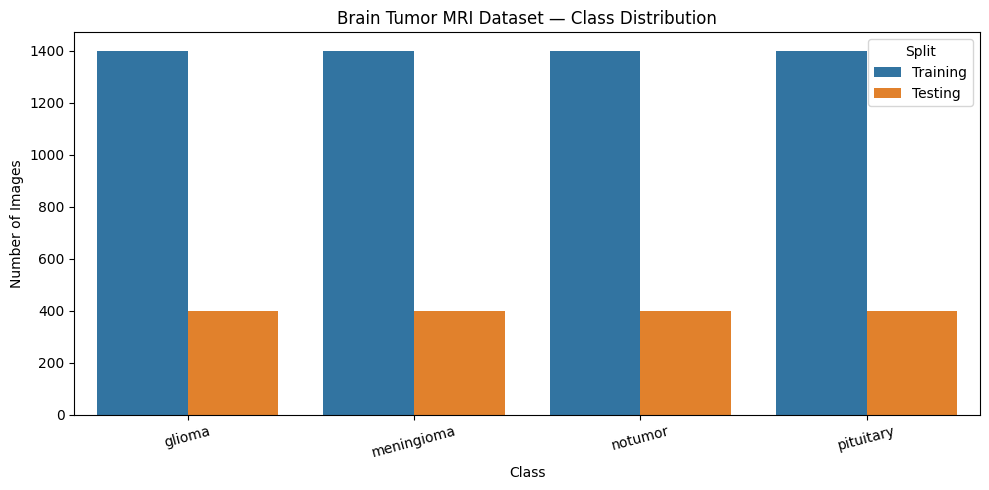

In [5]:

plt.figure(figsize=(10, 5))

sns.barplot(
    data=inventory_df,
    x="Class",
    y="Image Count",
    hue="Split"
)

plt.title("Brain Tumor MRI Dataset — Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [6]:

extension_counts = {}

for split_dir in [TRAIN_DIR, TEST_DIR]:
    for image_path in split_dir.rglob("*"):
        if image_path.is_file():
            extension = image_path.suffix.lower() or "[no extension]"
            extension_counts[extension] = (
                extension_counts.get(extension, 0) + 1
            )

extension_df = pd.DataFrame(
    extension_counts.items(),
    columns=["Extension", "Count"]
).sort_values("Count", ascending=False)

display(extension_df)

,Extension,Count
0,.jpg,7200


In [8]:

dimension_records = []

for split_name, split_dir in [
    ("Training", TRAIN_DIR),
    ("Testing", TEST_DIR)
]:
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue

        for image_path in get_image_files(class_dir):
            try:
                with Image.open(image_path) as img:
                    width, height = img.size

                    dimension_records.append({
                        "Split": split_name,
                        "Class": class_dir.name,
                        "Filename": image_path.name,
                        "Width": width,
                        "Height": height,
                        "Mode": img.mode,
                        "Format": img.format
                    })

            except (OSError, UnidentifiedImageError) as e:
                print(f"Could not inspect: {image_path} | {e}")

dimensions_df = pd.DataFrame(dimension_records)

print("Images inspected:", len(dimensions_df))
print("\nImage dimensions:")
display(
    dimensions_df[["Width", "Height"]]
    .describe()
    .round(2)
)

print("\nMost common dimensions:")
display(
    dimensions_df
    .groupby(["Width", "Height"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
    .head(15)
)

print("\nImage modes:")
display(dimensions_df["Mode"].value_counts().to_frame("Count"))

Images inspected: 7200

Image dimensions:


,Width,Height
count,7200.00,7200.0
mean,453.30,456.9
std,130.05,124.4
min,150.00,167.0
25%,442.00,449.0
50%,512.00,512.0
75%,512.00,512.0
max,1375.00,1446.0



Most common dimensions:


,Width,Height,Count
368,512,512,5014
95,225,225,338
405,630,630,90
25,201,251,57
105,228,221,51
115,232,217,50
156,236,236,48
329,442,442,48
0,150,198,44
19,200,252,43



Image modes:


,Count
Mode,
RGB,4129
L,3067
RGBA,3
P,1


In [9]:

import hashlib
from collections import defaultdict

hash_records = []

for split_name, split_dir in [
    ("Training", TRAIN_DIR),
    ("Testing", TEST_DIR)
]:
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue

        for image_path in get_image_files(class_dir):
            try:
                file_hash = hashlib.sha256(
                    image_path.read_bytes()
                ).hexdigest()

                hash_records.append({
                    "Split": split_name,
                    "Class": class_dir.name,
                    "Path": str(image_path),
                    "Hash": file_hash
                })

            except OSError as e:
                print(f"Could not hash {image_path}: {e}")

hash_df = pd.DataFrame(hash_records)

# Group identical file hashes
duplicate_groups = (
    hash_df.groupby("Hash")
    .filter(lambda group: len(group) > 1)
    .sort_values("Hash")
)

print("Files hashed:", len(hash_df))
print("Unique file hashes:", hash_df["Hash"].nunique())
print("Duplicate files beyond first copies:",
      len(hash_df) - hash_df["Hash"].nunique())

if not duplicate_groups.empty:
    display(duplicate_groups)
else:
    print("No exact byte-identical duplicates found.")

Files hashed: 7200
Unique file hashes: 7013
Duplicate files beyond first copies: 187


,Split,Class,Path,Hash
5921,Testing,glioma,D:\Projects\Medexplain_AI\ml\data\raw\dataset\...,04aa41d8514362877d7f8fd81e543bc8584e4a6ba1ac02...
5845,Testing,glioma,D:\Projects\Medexplain_AI\ml\data\raw\dataset\...,04aa41d8514362877d7f8fd81e543bc8584e4a6ba1ac02...
2853,Training,notumor,D:\Projects\Medexplain_AI\ml\data\raw\dataset\...,05ec18666c6b751b8845a93824ea25c9bb251606b71f76...
3595,Training,notumor,D:\Projects\Medexplain_AI\ml\data\raw\dataset\...,05ec18666c6b751b8845a93824ea25c9bb251606b71f76...
2282,Training,meningioma,D:\Projects\Medexplain_AI\ml\data\raw\dataset\...,089a7ad8107e9ef50fc7c35e7407b18fcda170be370774...
...,...,...,...,...
2977,Training,notumor,D:\Projects\Medexplain_AI\ml\data\raw\dataset\...,fd701e8cdd7a47b2b7198334e09d7947edf3d2efdd68b7...
3458,Training,notumor,D:\Projects\Medexplain_AI\ml\data\raw\dataset\...,fd701e8cdd7a47b2b7198334e09d7947edf3d2efdd68b7...
2859,Training,notumor,D:\Projects\Medexplain_AI\ml\data\raw\dataset\...,fd701e8cdd7a47b2b7198334e09d7947edf3d2efdd68b7...
3013,Training,notumor,D:\Projects\Medexplain_AI\ml\data\raw\dataset\...,fe20d08e5475898e9b66661cddbe32d6d006438e57c36c...


In [10]:

split_counts = (
    hash_df.groupby("Hash")["Split"]
    .nunique()
    .reset_index(name="Number of Splits")
)

cross_split_hashes = split_counts[
    split_counts["Number of Splits"] > 1
]

print("Exact duplicate hashes appearing across Training and Testing:",
      len(cross_split_hashes))

if not cross_split_hashes.empty:
    cross_split_details = hash_df[
        hash_df["Hash"].isin(cross_split_hashes["Hash"])
    ].sort_values(["Hash", "Split"])

    display(cross_split_details)
else:
    print("No exact byte-identical cross-split duplicates found.")

Exact duplicate hashes appearing across Training and Testing: 0
No exact byte-identical cross-split duplicates found.


In [11]:

# Count files for each exact hash
hash_group_summary = (
    hash_df.groupby("Hash")
    .agg(
        Copies=("Path", "count"),
        Classes=("Class", "nunique"),
        Splits=("Split", "nunique")
    )
    .reset_index()
)

duplicate_summary = hash_group_summary[
    hash_group_summary["Copies"] > 1
].copy()

print("Number of duplicate hash groups:", len(duplicate_summary))
print("Extra copies beyond first:", (duplicate_summary["Copies"] - 1).sum())

print("\nDuplicate groups by number of copies:")
display(
    duplicate_summary["Copies"]
    .value_counts()
    .sort_index()
    .rename_axis("Copies per hash")
    .to_frame("Number of groups")
)

print("\nDuplicate groups appearing in multiple classes:",
      (duplicate_summary["Classes"] > 1).sum())

print("Duplicate groups appearing in multiple splits:",
      (duplicate_summary["Splits"] > 1).sum())

Number of duplicate hash groups: 153
Extra copies beyond first: 187

Duplicate groups by number of copies:


,Number of groups
Copies per hash,
2,124
3,25
4,3
5,1



Duplicate groups appearing in multiple classes: 0
Duplicate groups appearing in multiple splits: 0


In [12]:

# Find exact hashes associated with more than one class
cross_class_hashes = duplicate_summary.loc[
    duplicate_summary["Classes"] > 1, "Hash"
]

cross_class_duplicates = hash_df[
    hash_df["Hash"].isin(cross_class_hashes)
].sort_values(["Hash", "Class", "Split"])

print("Files involved in cross-class duplicate groups:",
      len(cross_class_duplicates))

if cross_class_duplicates.empty:
    print("No exact duplicate hashes found across different classes.")
else:
    display(
        cross_class_duplicates[
            ["Split", "Class", "Path", "Hash"]
        ]
    )

Files involved in cross-class duplicate groups: 0
No exact duplicate hashes found across different classes.


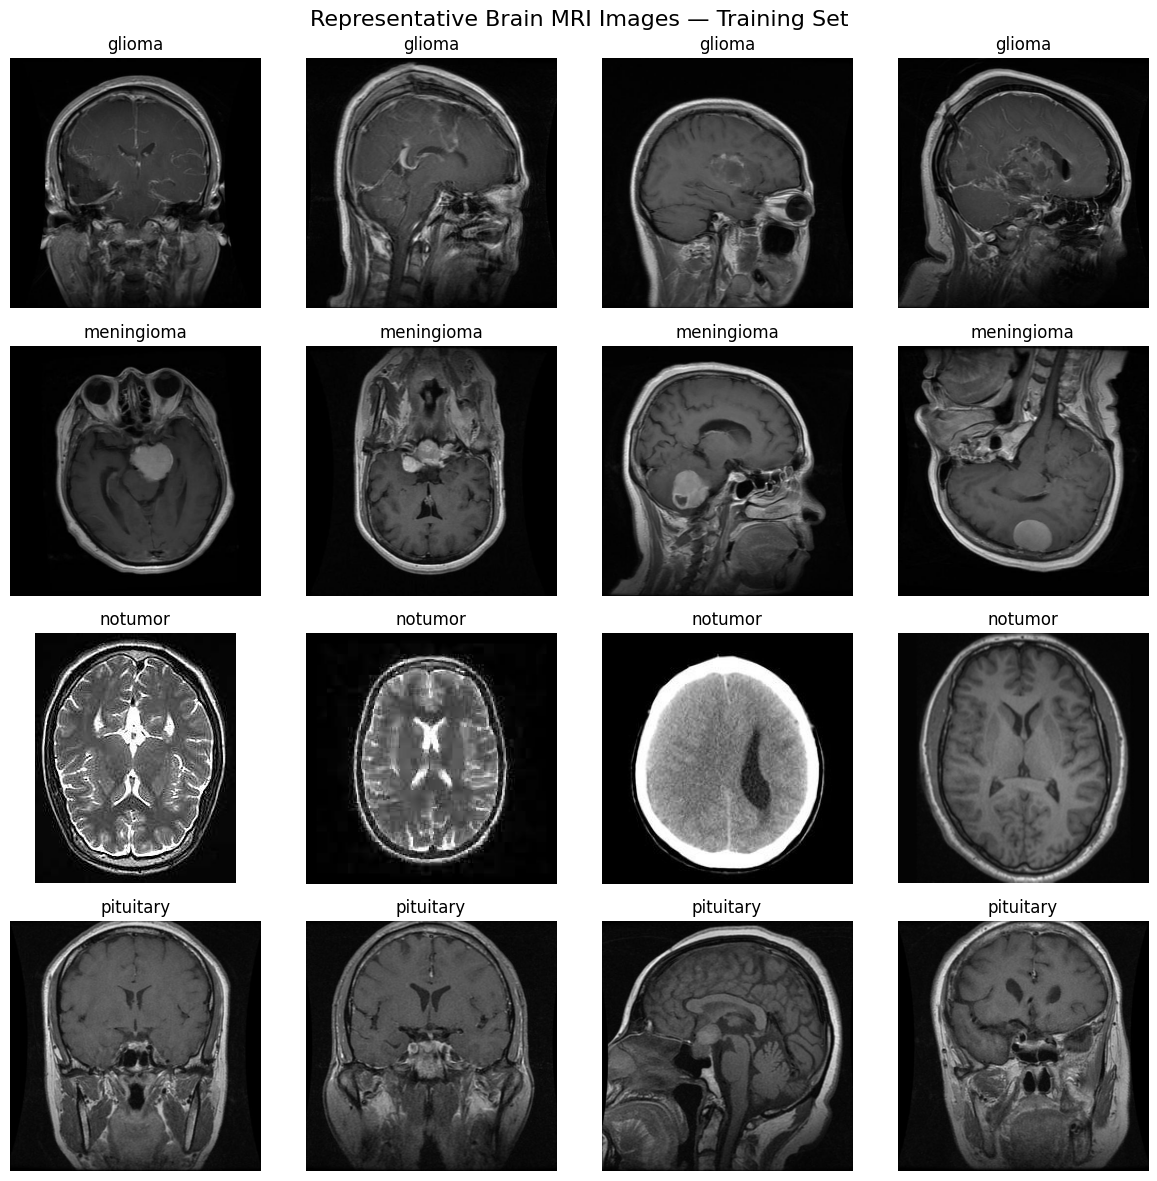

In [13]:

classes = ["glioma", "meningioma", "notumor", "pituitary"]

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for row, class_name in enumerate(classes):
    class_folder = TRAIN_DIR / class_name
    image_paths = get_image_files(class_folder)[:4]

    for col in range(4):
        ax = axes[row, col]

        if col < len(image_paths):
            with Image.open(image_paths[col]) as img:
                ax.imshow(img.convert("RGB"))

            ax.set_title(class_name)
        else:
            ax.set_visible(False)

        ax.axis("off")

plt.suptitle("Representative Brain MRI Images — Training Set", fontsize=16)
plt.tight_layout()
plt.show()

In [14]:

corrupted_images = []

for split_name, split_dir in [
    ("Training", TRAIN_DIR),
    ("Testing", TEST_DIR)
]:
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue

        for image_path in get_image_files(class_dir):
            try:
                with Image.open(image_path) as img:
                    img.verify()
            except (OSError, UnidentifiedImageError, ValueError) as e:
                corrupted_images.append({
                    "Split": split_name,
                    "Class": class_dir.name,
                    "Path": str(image_path),
                    "Error": str(e)
                })

print("Corrupted images:", len(corrupted_images))

if corrupted_images:
    display(pd.DataFrame(corrupted_images))
else:
    print("All images passed the integrity check.")

Corrupted images: 0
All images passed the integrity check.


In [15]:

import hashlib
import json
from PIL import Image, ImageOps
from collections import defaultdict

IMAGE_SIZE = (224, 224)

# Use a neutral black background when preserving aspect ratio.
PAD_COLOR = (0, 0, 0)

# These are the expected dataset class folder names.
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

# Output directories
PROCESSED_TRAIN_DIR = PROCESSED_DIR / "Training"
PROCESSED_TEST_DIR = PROCESSED_DIR / "Testing"

print("Target image size:", IMAGE_SIZE)
print("Processed output:", PROCESSED_DIR)
print("Raw data will remain unchanged.")

Target image size: (224, 224)
Processed output: D:\Projects\Medexplain_AI\ml\data\processed
Raw data will remain unchanged.


In [16]:

def preprocess_image(source_path, destination_path):
    """
    Open an image, convert it to RGB, resize while preserving
    aspect ratio, and save as PNG.
    """
    with Image.open(source_path) as img:
        img = img.convert("RGB")

        processed_img = ImageOps.pad(
            img,
            IMAGE_SIZE,
            method=Image.Resampling.LANCZOS,
            color=PAD_COLOR,
            centering=(0.5, 0.5)
        )

        destination_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        processed_img.save(
            destination_path,
            format="PNG",
            optimize=True
        )

In [17]:

preprocessing_records = []
seen_hashes = set()

processed_count = 0
duplicate_skipped_count = 0
failed_count = 0

for split_name, split_dir in [
    ("Training", TRAIN_DIR),
    ("Testing", TEST_DIR)
]:
    for class_name in CLASSES:
        class_dir = split_dir / class_name

        if not class_dir.exists():
            print(f"WARNING: Missing class folder: {class_dir}")
            continue

        # Reset hash tracking for each split/class.
        seen_hashes = set()

        for source_path in get_image_files(class_dir):
            try:
                file_hash = hashlib.sha256(
                    source_path.read_bytes()
                ).hexdigest()

                if file_hash in seen_hashes:
                    duplicate_skipped_count += 1

                    preprocessing_records.append({
                        "Split": split_name,
                        "Class": class_name,
                        "Source": str(source_path),
                        "Status": "duplicate_skipped",
                        "Hash": file_hash
                    })
                    continue

                seen_hashes.add(file_hash)

                destination_path = (
                    PROCESSED_DIR
                    / split_name
                    / class_name
                    / f"{source_path.stem}.png"
                )

                preprocess_image(
                    source_path,
                    destination_path
                )

                processed_count += 1

                preprocessing_records.append({
                    "Split": split_name,
                    "Class": class_name,
                    "Source": str(source_path),
                    "Output": str(destination_path),
                    "Status": "processed",
                    "Hash": file_hash
                })

            except Exception as e:
                failed_count += 1

                preprocessing_records.append({
                    "Split": split_name,
                    "Class": class_name,
                    "Source": str(source_path),
                    "Status": "failed",
                    "Error": str(e)
                })

preprocessing_df = pd.DataFrame(preprocessing_records)

print("Successfully processed:", processed_count)
print("Duplicate copies skipped:", duplicate_skipped_count)
print("Failed:", failed_count)

Successfully processed: 7013
Duplicate copies skipped: 187
Failed: 0


In [18]:

verification_errors = []
verified_count = 0

for split_name in ["Training", "Testing"]:
    for class_name in CLASSES:
        folder = PROCESSED_DIR / split_name / class_name

        if not folder.exists():
            continue

        for image_path in get_image_files(folder):
            try:
                with Image.open(image_path) as img:
                    if img.size != IMAGE_SIZE:
                        verification_errors.append(
                            f"Wrong dimensions: {image_path} {img.size}"
                        )

                    if img.mode != "RGB":
                        verification_errors.append(
                            f"Wrong mode: {image_path} {img.mode}"
                        )

                    verified_count += 1

            except Exception as e:
                verification_errors.append(
                    f"Could not open {image_path}: {e}"
                )

print("Processed images checked:", verified_count)
print("Verification errors:", len(verification_errors))

if verification_errors:
    for error in verification_errors[:20]:
        print(error)
else:
    print("All processed images are 224x224 RGB.")

Processed images checked: 7013
Verification errors: 0
All processed images are 224x224 RGB.


In [19]:

report = {
    "dataset": "Brain Tumor MRI Dataset",
    "source_directory": str(DATASET_DIR),
    "processed_directory": str(PROCESSED_DIR),
    "classes": CLASSES,
    "original_total_images": 7200,
    "original_training_images": 5600,
    "original_testing_images": 1600,
    "corrupted_images_detected": 0,
    "original_unique_exact_hashes": 7013,
    "duplicate_copies_skipped": duplicate_skipped_count,
    "processed_images": processed_count,
    "failed_images": failed_count,
    "target_dimensions": list(IMAGE_SIZE),
    "color_mode": "RGB",
    "resize_method": "Aspect-ratio-preserving padding",
    "raw_dataset_modified": False
}

report_path = PROJECT_ROOT / "ml" / "reports" / "preprocessing_report.json"
report_path.parent.mkdir(parents=True, exist_ok=True)

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=4)

print("Report saved to:", report_path)

Report saved to: D:\Projects\Medexplain_AI\ml\reports\preprocessing_report.json
